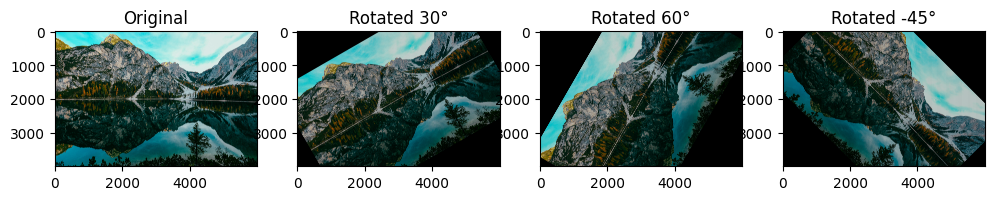

In [4]:
#1. A function to perform rotation on a given image by a specified angle (in degrees):
import numpy as np
import math

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import math

# Function to rotate the image
def rotate_image(image, angle):
    angle_rad = math.radians(angle)
    h, w = image.shape[:2]
    rotation_matrix = np.array([[np.cos(angle_rad), -np.sin(angle_rad)],
                                [np.sin(angle_rad),  np.cos(angle_rad)]])
    center_x, center_y = w // 2, h // 2
    rotated_image = np.zeros_like(image)

    for i in range(h):
        for j in range(w):
            y, x = i - center_y, j - center_x
            new_y, new_x = np.dot(rotation_matrix, np.array([y, x]))
            new_y, new_x = int(new_y + center_y), int(new_x + center_x)
            if 0 <= new_x < w and 0 <= new_y < h:
                rotated_image[new_y, new_x] = image[i, j]

    return rotated_image

# Load the image
image_path = "/content/sample_data/RGB image 2.jpg"
image = np.array(Image.open(image_path))

# Rotate the image with different angles
angles = [30, 60, -45]
rotated_images = [rotate_image(image, angle) for angle in angles]

# Plot the original and rotated images
plt.figure(figsize=(12, 12))
plt.subplot(1, 4, 1)
plt.imshow(image)
plt.title('Original')

for i, rotated_image in enumerate(rotated_images):
    plt.subplot(1, 4, i + 2)
    plt.imshow(rotated_image)
    plt.title(f'Rotated {angles[i]}°')

plt.show()



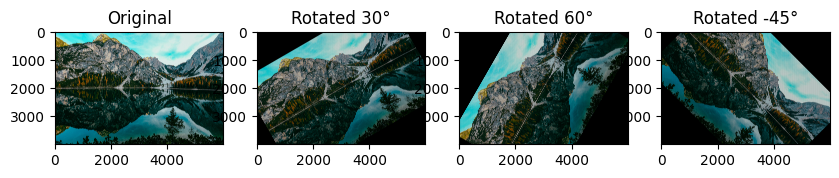

In [5]:
#2. Apply the rotation function to a set of images with varying rotation angles and visualize the results
import matplotlib.pyplot as plt
from PIL import Image

# Load an image  (convert it to grayscale or RGB)
image = np.array(Image.open('/content/sample_data/RGB image 2.jpg'))

# Apply your rotation function for different angles
angles = [30, 60, -45]
rotated_images = [rotate_image(image, angle) for angle in angles]

# Display original and rotated images
plt.figure(figsize=(10, 10))

plt.subplot(1, 4, 1)
plt.imshow(image)
plt.title('Original')

for i, rotated_image in enumerate(rotated_images):
    plt.subplot(1, 4, i + 2)
    plt.imshow(rotated_image)
    plt.title(f'Rotated {angles[i]}°')

plt.show()


Custom rotation time: 889.8738 seconds
OpenCV rotation time: 1.9320 seconds


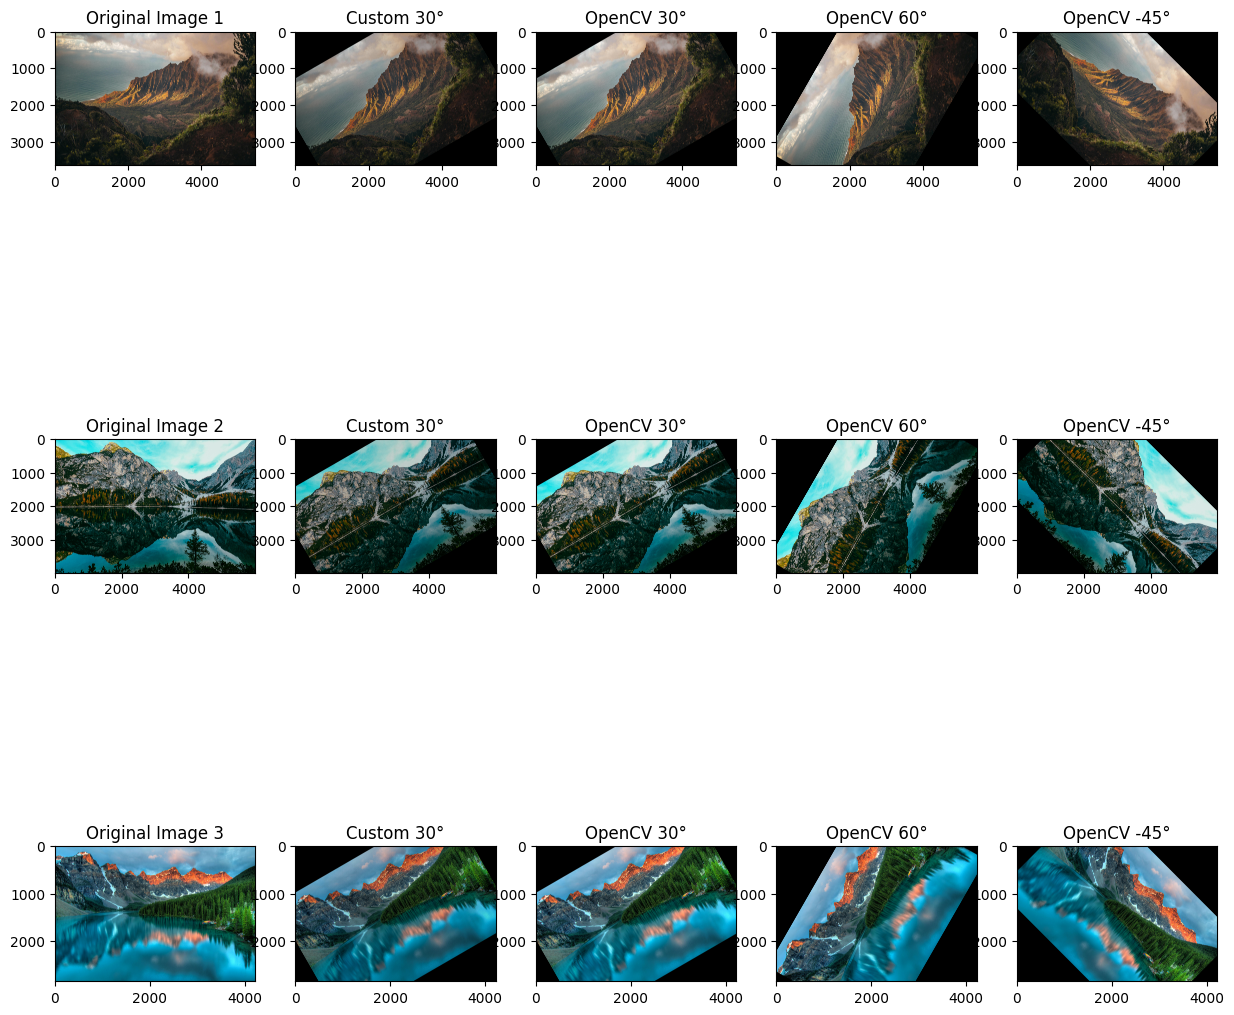

In [10]:
#3. Compare the results with a built-in rotation function (e.g., OpenCV)
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt
from PIL import Image
import math

# Function to rotate the image using custom implementation
def rotate_image(image, angle):
    angle_rad = math.radians(angle)
    h, w = image.shape[:2]
    rotation_matrix = np.array([[np.cos(angle_rad), -np.sin(angle_rad)],
                                [np.sin(angle_rad),  np.cos(angle_rad)]])
    center_x, center_y = w // 2, h // 2
    rotated_image = np.zeros_like(image)

    for i in range(h):
        for j in range(w):
            y, x = i - center_y, j - center_x
            new_y, new_x = np.dot(rotation_matrix, np.array([y, x]))
            new_y, new_x = int(new_y + center_y), int(new_x + center_x)
            if 0 <= new_x < w and 0 <= new_y < h:
                rotated_image[new_y, new_x] = image[i, j]

    return rotated_image

# OpenCV rotation function
def rotate_with_opencv(image, angle):
    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated_image = cv2.warpAffine(image, rotation_matrix, (w, h))
    return rotated_image


image_paths = ["/content/sample_data/RGB image 1.jpg", "/content/sample_data/RGB image 2.jpg", "/content/sample_data/RGB image 3.jpg"]
images = [np.array(Image.open(path)) for path in image_paths]  # Load images

# Define rotation angles
angles = [30, 60, -45]

# Timing the execution for comparison
start_time_custom = time.time()
rotated_images_custom = [rotate_image(image, angle) for image in images for angle in angles]
end_time_custom = time.time()
print(f"Custom rotation time: {end_time_custom - start_time_custom:.4f} seconds")

start_time_opencv = time.time()
rotated_images_opencv = [rotate_with_opencv(image, angle) for image in images for angle in angles]
end_time_opencv = time.time()
print(f"OpenCV rotation time: {end_time_opencv - start_time_opencv:.4f} seconds")

# Function to visualize the results
def compare_rotations(images, angles):
    plt.figure(figsize=(15, 15))

    for img_index, image in enumerate(images):
        # Rotate the image with different angles using both methods
        rotated_images_custom = [rotate_image(image, angle) for angle in angles]
        rotated_images_opencv = [rotate_with_opencv(image, angle) for angle in angles]

        # Display original image
        plt.subplot(len(images), 5, img_index * 5 + 1)
        plt.imshow(image)
        plt.title(f'Original Image {img_index + 1}')

        # Display custom rotated images
        for i, rotated_image in enumerate(rotated_images_custom):
            plt.subplot(len(images), 5, img_index * 5 + i + 2)
            plt.imshow(rotated_image)
            plt.title(f'Custom {angles[i]}°')

        # Display OpenCV rotated images
        for i, rotated_image in enumerate(rotated_images_opencv):
            plt.subplot(len(images), 5, img_index * 5 + i + 3)
            plt.imshow(rotated_image)
            plt.title(f'OpenCV {angles[i]}°')

    plt.show()

# Call the function to compare both rotations
compare_rotations(images, angles)


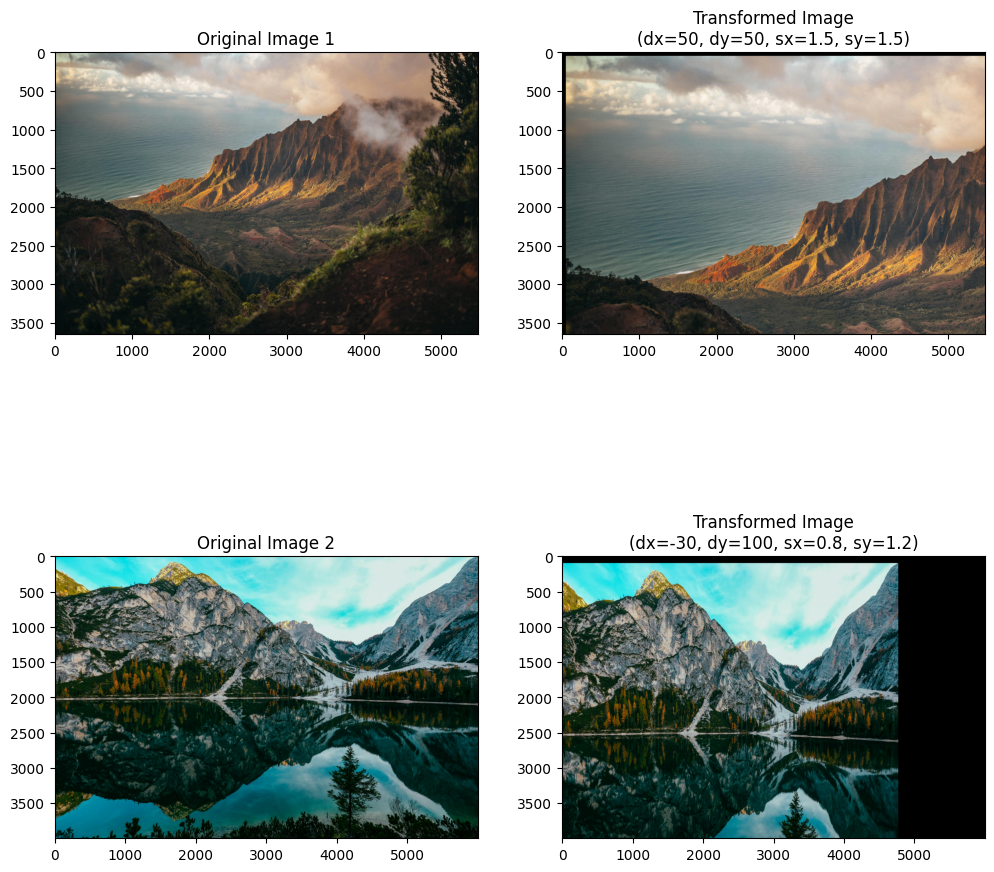

In [11]:
#Task 2: Transformation Matrix Calculation
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Function to create a transformation matrix for translation and scaling
def calculate_transformation_matrix(dx, dy, sx, sy):
    transformation_matrix = np.array([[sx, 0,  dx],
                                      [0,  sy, dy],
                                      [0,  0,  1]])
    return transformation_matrix

# Function to apply the transformation matrix to an image using OpenCV's warpAffine
def apply_transformation(image, transformation_matrix):
    h, w = image.shape[:2]
    # Extract the 2x3 part of the matrix for OpenCV (since OpenCV's warpAffine expects a 2x3 matrix)
    affine_matrix = transformation_matrix[:2, :]
    transformed_image = cv2.warpAffine(image, affine_matrix, (w, h))
    return transformed_image

# Visualize original and transformed images
def visualize_transformation(images, transformations):
    plt.figure(figsize=(12, 12))

    for img_index, (image, (dx, dy, sx, sy)) in enumerate(zip(images, transformations)):
        # Calculate transformation matrix
        matrix = calculate_transformation_matrix(dx, dy, sx, sy)
        # Apply the transformation to the image
        transformed_image = apply_transformation(image, matrix)

        # Plot original image
        plt.subplot(len(images), 2, img_index * 2 + 1)
        plt.imshow(image)
        plt.title(f'Original Image {img_index + 1}')

        # Plot transformed image
        plt.subplot(len(images), 2, img_index * 2 + 2)
        plt.imshow(transformed_image)
        plt.title(f'Transformed Image\n(dx={dx}, dy={dy}, sx={sx}, sy={sy})')

    plt.show()


image_paths = ["/content/sample_data/RGB image 1.jpg", "/content/sample_data/RGB image 2.jpg"]
images = [np.array(Image.open(path)) for path in image_paths]

# Define the translation and scaling parameters (dx, dy, sx, sy) for each image
transformations = [
    (50, 50, 1.5, 1.5),  # Translation by (50, 50) and scaling by 1.5 on both axes
    (-30, 100, 0.8, 1.2) # Translation by (-30, 100) and scaling by 0.8 on x and 1.2 on y
]

# Call the function to visualize original and transformed images
visualize_transformation(images, transformations)


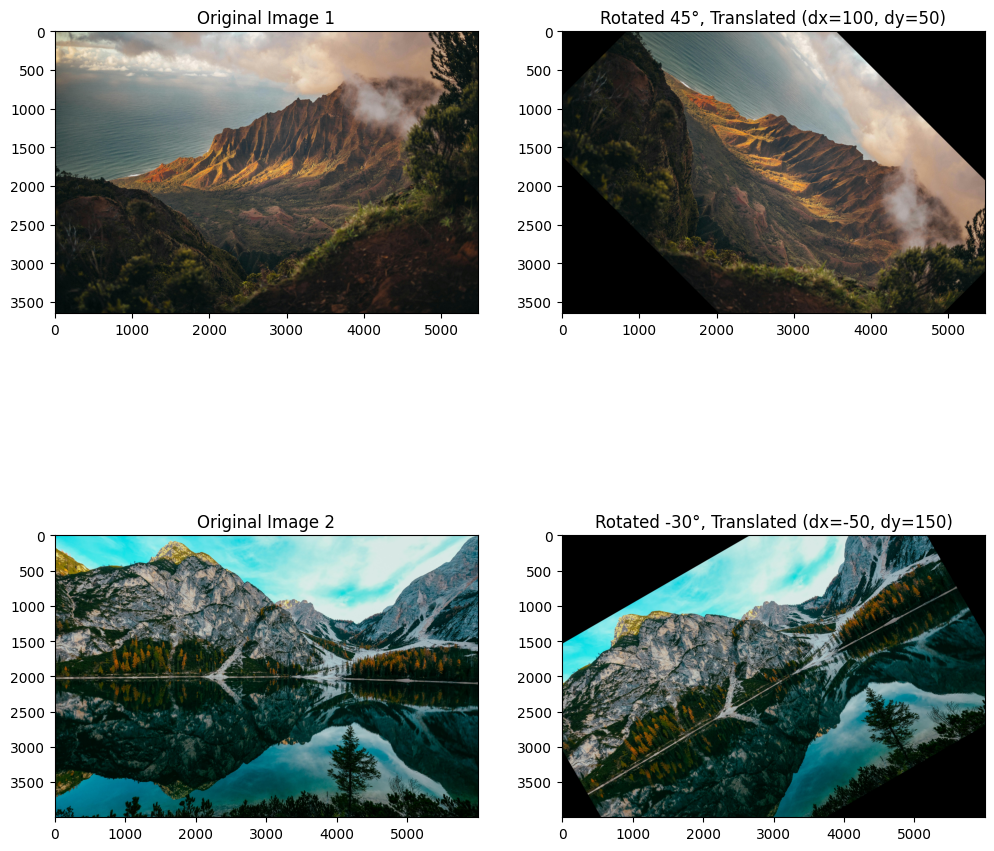

In [17]:
#Task 3: Combining Transformations
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import math

# Function to create a rotation matrix
def calculate_rotation_matrix(angle, center):
    angle_rad = math.radians(angle)
    cos_theta = np.cos(angle_rad)
    sin_theta = np.sin(angle_rad)

    cx, cy = center
    rotation_matrix = np.array([[cos_theta, -sin_theta, cx - cx * cos_theta + cy * sin_theta],
                                [sin_theta,  cos_theta, cy - cx * sin_theta - cy * cos_theta],
                                [0, 0, 1]])
    return rotation_matrix

# Function to create a translation matrix
def calculate_translation_matrix(dx, dy):
    translation_matrix = np.array([[1, 0, dx],
                                   [0, 1, dy],
                                   [0, 0, 1]])
    return translation_matrix

# Function to combine rotation and translation transformations
def combine_transformations(image, angle, dx, dy):
    h, w = image.shape[:2]
    center = (w // 2, h // 2)

    # Calculate the transformation matrices
    rotation_matrix = calculate_rotation_matrix(angle, center)
    translation_matrix = calculate_translation_matrix(dx, dy)

    # Combine the transformations (translation after rotation)
    combined_matrix = np.dot(translation_matrix, rotation_matrix)

    # Apply the combined transformation
    affine_matrix = combined_matrix[:2, :]  # Extract the 2x3 part for OpenCV
    transformed_image = cv2.warpAffine(image, affine_matrix, (w, h))

    return transformed_image

# Function to visualize original and combined transformed images
def visualize_combined_transformations(images, transformations):
    plt.figure(figsize=(12, 12))

    for img_index, (image, (angle, dx, dy)) in enumerate(zip(images, transformations)):
        # Apply combined transformations (rotation + translation)
        transformed_image = combine_transformations(image, angle, dx, dy)

        # Plot original image
        plt.subplot(len(images), 2, img_index * 2 + 1)
        plt.imshow(image)
        plt.title(f'Original Image {img_index + 1}')

        # Plot transformed image
        plt.subplot(len(images), 2, img_index * 2 + 2)
        plt.imshow(transformed_image)
        plt.title(f'Rotated {angle}°, Translated (dx={dx}, dy={dy})')

    plt.show()


image_paths = ["/content/sample_data/RGB image 1.jpg", "/content/sample_data/RGB image 2.jpg"]

# Load images, ensure they are in RGB format
images = []
for path in image_paths:
    try:
        img = Image.open(path).convert('RGB')  # Convert to RGB if necessary
        images.append(np.array(img))
    except Exception as e:
        print(f"Error loading image {path}: {e}")

# Define the transformation parameters (angle, dx, dy) for each image
transformations = [
    (45, 100, 50),   # Rotate by 45° and translate by (100, 50)
    (-30, -50, 150)  # Rotate by -30° and translate
]

# Call the function to visualize original and transformed images
if images:
    visualize_combined_transformations(images, transformations)
else:
    print("No images to display.")
